del net
torch.cuda.empty_cache()

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
import os
root = "/workspace"
train_metadata = f"{root}/data/training_frames_keypoints.csv"
test_metadata = f"{root}/data/test_frames_keypoints.csv"
assert os.path.isfile(train_metadata), f"File {train_metadata} does not exist."
assert os.path.isfile(test_metadata), f"File {test_metadata} does not exist."

In [3]:
import pandas as pd
metadata_df = pd.read_csv(train_metadata)
print(metadata_df.head())

                   Unnamed: 0     0     1     2      3     4      5     6  \
0           Luis_Fonsi_21.jpg  45.0  98.0  47.0  106.0  49.0  110.0  53.0   
1       Lincoln_Chafee_52.jpg  41.0  83.0  43.0   91.0  45.0  100.0  47.0   
2       Valerie_Harper_30.jpg  56.0  69.0  56.0   77.0  56.0   86.0  56.0   
3         Angelo_Reyes_22.jpg  61.0  80.0  58.0   95.0  58.0  108.0  58.0   
4  Kristen_Breitweiser_11.jpg  58.0  94.0  58.0  104.0  60.0  113.0  62.0   

       7     8  ...   126    127    128    129   130    131   132    133  \
0  119.0  56.0  ...  83.0  119.0   90.0  117.0  83.0  119.0  81.0  122.0   
1  108.0  51.0  ...  85.0  122.0   94.0  120.0  85.0  122.0  83.0  122.0   
2   94.0  58.0  ...  79.0  105.0   86.0  108.0  77.0  105.0  75.0  105.0   
3  120.0  58.0  ...  98.0  136.0  107.0  139.0  95.0  139.0  91.0  139.0   
4  121.0  67.0  ...  92.0  117.0  103.0  118.0  92.0  120.0  88.0  122.0   

    134    135  
0  77.0  122.0  
1  79.0  122.0  
2  73.0  105.0  
3  85.0  136

0 (192, 176, 4) (68, 2)
1 (196, 157, 4) (68, 2)
2 (190, 170, 4) (68, 2)
3 (240, 213, 4) (68, 2)


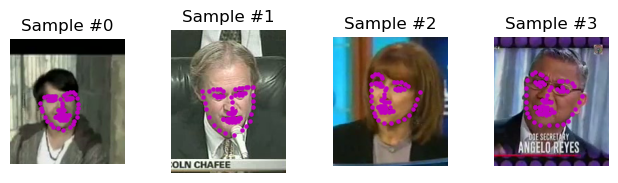

In [4]:
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt

class FacialKeypointsDataset(Dataset):
    def __init__(self, csv_file, transform = None, dir = f'{root}/data/training/'):
        self.key_pts_frame = pd.read_csv(csv_file)
        self.transform = transform
        self.dir = dir

    def __len__(self):
        return self.key_pts_frame.shape[0]
    
    def __getitem__(self, idx):
        image_name = self.key_pts_frame.iloc[idx, 0]
        image_path = os.path.join(self.dir, image_name)
        image = plt.imread(image_path)
        key_pts = self.key_pts_frame.iloc[idx, 1:].values.reshape(-1, 2).astype('float')
        sample = {'image': image, 'keypoints': key_pts}
        if self.transform:
            sample = self.transform(sample)
        return sample
    
example_dataset = FacialKeypointsDataset(csv_file=train_metadata)
fig = plt.figure()
for i in range(4):
    sample = example_dataset[i]
    print(i, sample['image'].shape, sample['keypoints'].shape)
    ax = plt.subplot(1, 4, i + 1)
    plt.tight_layout()
    ax.set_title('Sample #{}'.format(i))
    ax.axis('off')
    plt.imshow(sample['image'])
    keypts_x = sample['keypoints'][:,0]
    keypts_y = sample['keypoints'][:,1]
    plt.scatter(keypts_x, keypts_y, s=20, marker='.', c='m')

In [5]:
from data_load import Rescale, RandomCrop, Normalize, ToTensor
from torchvision.transforms import v2

data_transform = v2.Compose([
    Rescale(250),
    RandomCrop(224),
    Normalize(mean=[ 98.49069732, 110.45427668], std=[42.7988386 , 42.71434865]),
    ToTensor()
])

train_dataset = FacialKeypointsDataset(csv_file=train_metadata, transform=data_transform, dir=f'{root}/data/training/')
test_dataset = FacialKeypointsDataset(csv_file=test_metadata, transform=data_transform, dir=f'{root}/data/test/')
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

In [11]:
from torch import nn, optim
class Block(nn.Module):
    def __init__(self, in_channels, out_channels, kernels=[3], stride=1):
        super(Block, self).__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        ]
        for kernel in kernels:
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=kernel, stride=stride, padding=kernel//2))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        self.sequence = nn.Sequential(*layers)

    def forward(self, x):
        return self.sequence(x)
    
net = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1)),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
    nn.ReLU(),
    Block(32,64, kernels=[5, 5]),
    nn.MaxPool2d(kernel_size=2, stride=2),
    Block(64,128, kernels=[5, 5]),
    nn.MaxPool2d(kernel_size=2, stride=2),
    Block(128,256, kernels=[5, 5]),
    nn.MaxPool2d(kernel_size=2, stride=2),
    Block(256,512, kernels=[5, 5]),
    nn.MaxPool2d(kernel_size=2, stride=2),
    Block(512,512, kernels=[5, 5]),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(start_dim=1, end_dim=-1),
    nn.Linear(in_features=4608, out_features=2048, bias=True),
    nn.ReLU(),
    nn.Linear(in_features=2048, out_features=512, bias=True),
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=136, bias=True),
)


net.cuda()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (2): ReLU()
  (3): Block(
    (sequence): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): ReLU()
    )
  )
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Block(
    (sequence): Sequential(
      (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      (1): Conv2d(128, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (2): Conv2d(128, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4

In [12]:
class L4Loss(nn.Module):
    def __init__(self):
        super(L4Loss, self).__init__()

    def forward(self, pred, target):
        return torch.mean((pred - target) ** 4)

In [13]:
optimizer = optim.AdamW(net.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [14]:
def train_model(net, train_loader, criterion, optimizer, num_epochs=10):
    net.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, sample in enumerate(train_loader):
            images = sample['image'].float().cuda()
            keypoints = sample['keypoints'].view(-1, 136).float().cuda()
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, keypoints)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            if (i + 1) % 10 == 0:
                print(f'Batch {i+1}/{len(train_loader)}, Loss: {loss.item():.4f}')
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

In [19]:
epochs = 20
train_model(net, train_loader, criterion, optimizer, num_epochs=epochs)

Batch 10/28, Loss: 0.0347
Batch 20/28, Loss: 0.0354
Epoch 1/20, Loss: 0.0445
Batch 10/28, Loss: 0.0851
Batch 20/28, Loss: 0.0328
Epoch 2/20, Loss: 0.0417
Batch 10/28, Loss: 0.0289
Batch 20/28, Loss: 0.0970
Epoch 3/20, Loss: 0.0365
Batch 10/28, Loss: 0.0290
Batch 20/28, Loss: 0.0342
Epoch 4/20, Loss: 0.0405
Batch 10/28, Loss: 0.0513
Batch 20/28, Loss: 0.0311
Epoch 5/20, Loss: 0.0352
Batch 10/28, Loss: 0.0285
Batch 20/28, Loss: 0.0342
Epoch 6/20, Loss: 0.0427
Batch 10/28, Loss: 0.0304
Batch 20/28, Loss: 0.0277
Epoch 7/20, Loss: 0.0535
Batch 10/28, Loss: 0.0292
Batch 20/28, Loss: 0.0311
Epoch 8/20, Loss: 0.0382
Batch 10/28, Loss: 0.0341
Batch 20/28, Loss: 0.0335
Epoch 9/20, Loss: 0.0378
Batch 10/28, Loss: 0.0304
Batch 20/28, Loss: 0.0288
Epoch 10/20, Loss: 0.0343
Batch 10/28, Loss: 0.1129
Batch 20/28, Loss: 0.0460
Epoch 11/20, Loss: 0.0419
Batch 10/28, Loss: 0.0424
Batch 20/28, Loss: 0.0326
Epoch 12/20, Loss: 0.0370
Batch 10/28, Loss: 0.0241
Batch 20/28, Loss: 0.0256
Epoch 13/20, Loss: 0.

In [20]:
def visualize_output(net, data_loader):
    net.eval()
    with torch.no_grad():
        sample = next(iter(data_loader))
        images = sample['image'].float().cuda()
        keypoints = sample['keypoints'].view(-1, 136).float()
        outputs = net(images)
        outputs = outputs.cpu().numpy()
        plt.subplots(8, 3, figsize=(8, 20))
        for j in range(min(24, images.size(0))):
            plt.subplot(8, 3, j + 1)
            plt.imshow(sample['image'][j].cpu().numpy().squeeze(), cmap='gray')
            pred_keypts_x = outputs[j][0::2] * 42.7988386 + 98.49069732
            pred_keypts_y = outputs[j][1::2] * 42.71434865 + 110.45427668
            true_keypts_x = keypoints[j][0::2] * 42.7988386 + 98.49069732
            true_keypts_y = keypoints[j][1::2] * 42.71434865 + 110.45427668
            plt.scatter(pred_keypts_x, pred_keypts_y, s=20, marker='.', c='r', label='Predicted')
            plt.scatter(true_keypts_x, true_keypts_y, s=20, marker='.', c='g', label='True')
            plt.legend()
            plt.title(f'Sample {i*data_loader.batch_size + j}')
            plt.axis('off')
    plt.tight_layout()
    plt.show()

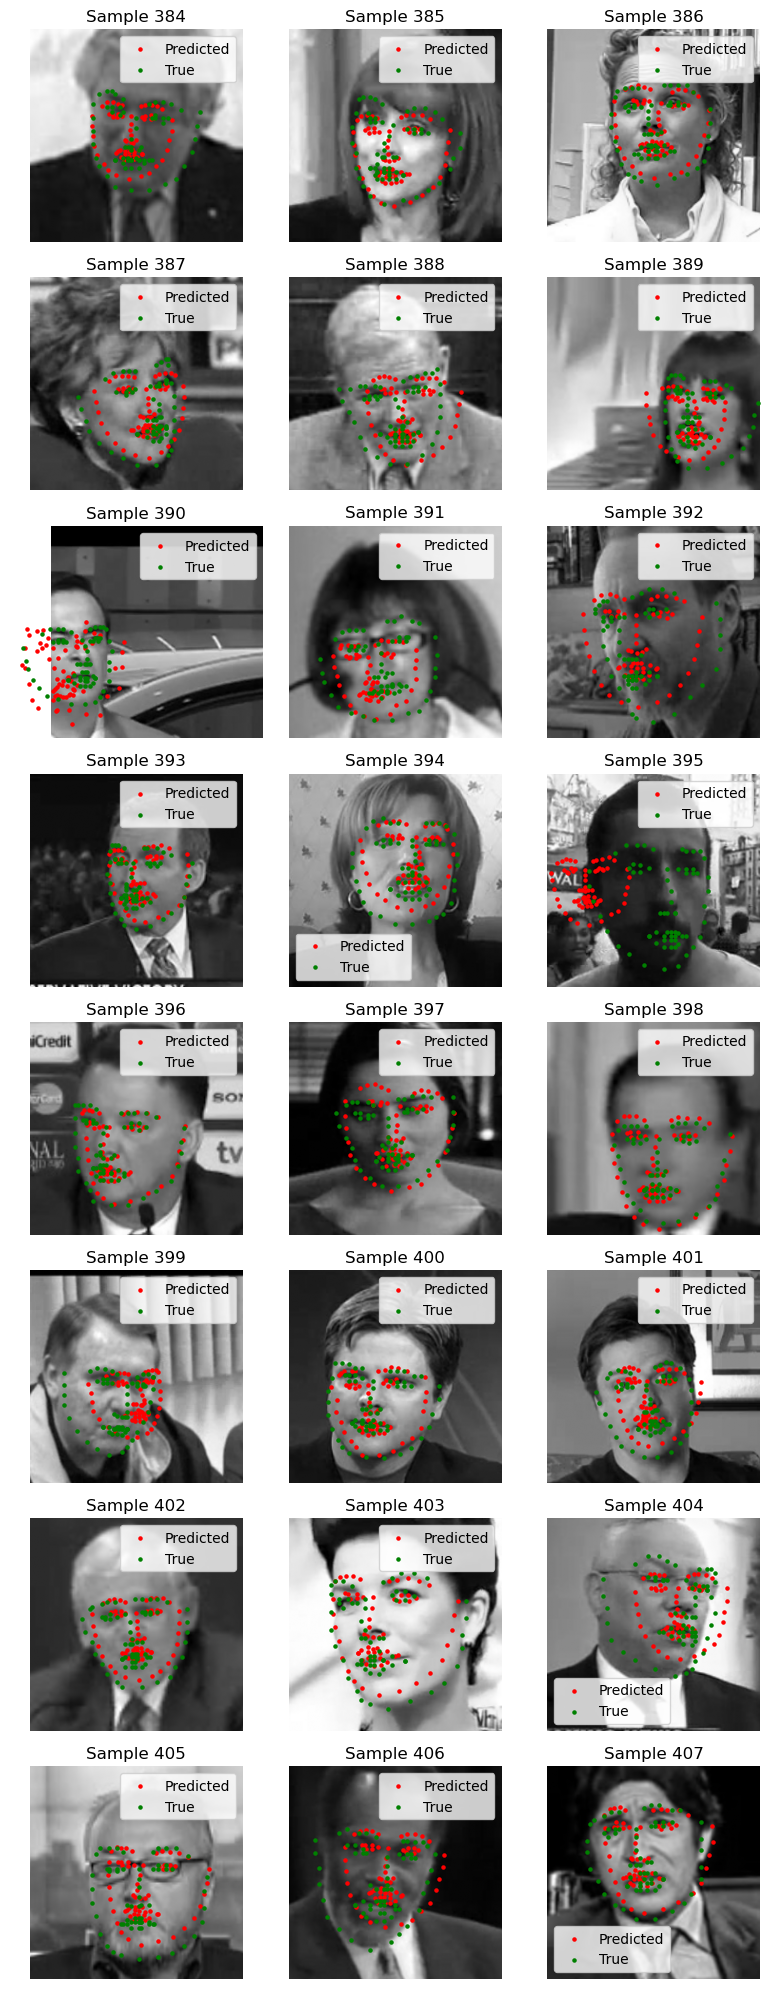

In [21]:
visualize_output(net, test_loader)

In [18]:
def get_test_loss(net, test_loader, criterion):
    net.eval()
    total_loss = 0.0
    with torch.no_grad():
        for sample in test_loader:
            images = sample['image'].float().cuda()
            keypoints = sample['keypoints'].view(-1, 136).float().cuda()
            outputs = net(images)
            loss = criterion(outputs, keypoints)
            total_loss += loss.item() * images.size(0)
    average_loss = total_loss / len(test_loader.dataset)
    if not os.path.exists(f'test_res'):
        os.makedirs(f'test_res')
    file_num = len(os.listdir(f'test_res'))
    with open(f'test_res/test_loss_{file_num}.txt', 'w') as f:
        f.write(f'Test Loss: {average_loss:.4f}\n\n')
        f.write(str(net))
    return {'average_loss': average_loss, 'file_num': file_num}

test_results = get_test_loss(net, test_loader, criterion)
print(f"Test Loss: {test_results['average_loss']:.4f}")
print(f"Results saved in test_res/test_loss_{test_results['file_num']}.txt")

Test Loss: 0.0364
Results saved in test_res/test_loss_9.txt
